node 1: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 2: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 3: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 4: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 5: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 6: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 7: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 8: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 9: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000
node 10: 7619 frames, 2025-08-12 10:50:42 to 2025-08-12 11:16:05.600000

Graces_Quarters RSSI instance
nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
rows: 7614 valid: 7490
time range: 2025-08-12 10:50:43 to 2025-08-12 11:16:05.600000
projected CRS: EPSG:32618
valid timesteps: 7490
ordered nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
temporal features: 1/7490
temporal feat

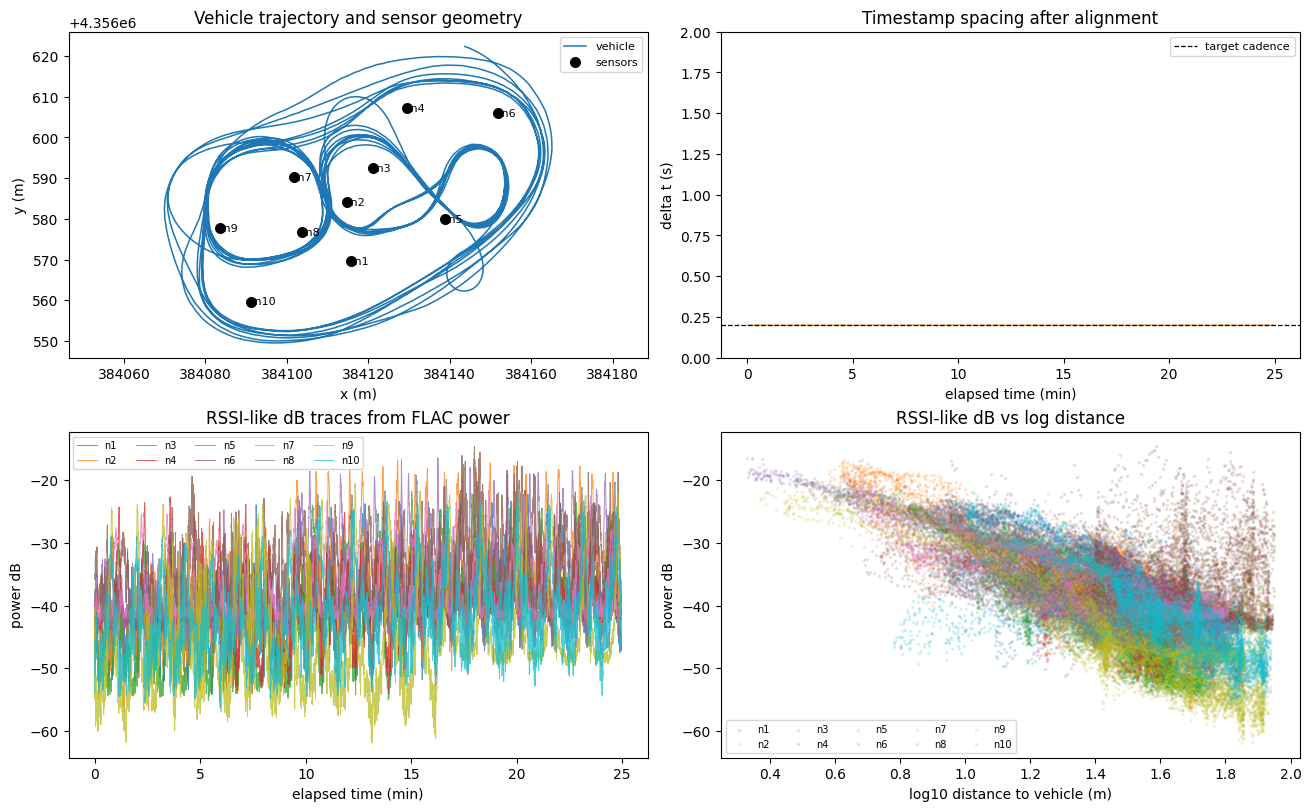

In [1]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.graces_quarters_rssi_two_tower as gq
gq = importlib.reload(gq)

DATASET_PREFIX = gq.DEFAULT_PREFIX
SAMPLE_MS = 200
FORCE_REBUILD = False

processed = gq.build_and_save_processed(
    PROJECT_ROOT,
    prefix=DATASET_PREFIX,
    sample_ms=SAMPLE_MS,
    max_subset_size=3,
    force=FORCE_REBUILD,
)

processed_dir = PROJECT_ROOT / "data" / "processed"
arrays = np.load(processed_dir / f"{DATASET_PREFIX}_arrays.npz", allow_pickle=True)
with open(processed_dir / f"{DATASET_PREFIX}_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

feature_wide = pd.read_csv(processed_dir / f"{DATASET_PREFIX}_feature_wide.csv", parse_dates=["datetime"]).set_index("datetime")
node_features = pd.read_csv(processed_dir / f"{DATASET_PREFIX}_node_features.csv", parse_dates=["datetime"])
gt_nodes = pd.read_csv(processed_dir / f"{DATASET_PREFIX}_ground_truth_nodes.csv", parse_dates=["datetime"])
gt_vehicle = pd.read_csv(processed_dir / f"{DATASET_PREFIX}_ground_truth_vehicle.csv", parse_dates=["datetime"])
sensor_geometry = pd.read_csv(processed_dir / f"{DATASET_PREFIX}_sensor_geometry.csv")
examples_index = pd.read_csv(processed_dir / f"{DATASET_PREFIX}_examples_index.csv")

ordered_nodes = [int(node) for node in meta["ordered_nodes"]]
rssi07_context_features = [
    name
    for node in ordered_nodes
    for name in (f"n{node}_sensor_x_norm", f"n{node}_sensor_y_norm", f"n{node}_rssi_db")
]
rssi07_static_action_features = (
    [f"mask_n{node}" for node in ordered_nodes]
    + [
        f"slot{slot}_sensor_{axis}_norm"
        for slot in range(1, 4)
        for axis in ("x", "y")
    ]
    + ["subset_size"]
)

missing_context = [name for name in rssi07_context_features if name not in meta["context_feature_names"]]
if missing_context:
    raise KeyError(f"Missing notebook-07 RSSI context features: {missing_context}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("dataset prefix:", DATASET_PREFIX)
print("ordered nodes:", ordered_nodes)
print("time range:", feature_wide.index.min(), "to", feature_wide.index.max())
print("valid timesteps:", meta["num_times"])
print("candidate subsets per timestamp:", meta["num_actions_per_time"])
print("examples:", meta["num_examples"])
print("full processed C_by_time:", arrays["C_by_time"].shape)
print("full processed A_examples:", arrays["A_examples"].shape)
print("notebook-07 RSSI-only context_dim:", len(rssi07_context_features))
print("notebook-07 static action_dim:", len(rssi07_static_action_features))
print("RSSI-only context features:")
print(rssi07_context_features)
print("Static action features:")
print(rssi07_static_action_features)

merged_node = node_features.merge(
    gt_nodes[["datetime", "node", "distance_to_vehicle_m"]],
    on=["datetime", "node"],
    how="inner",
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

ax = axes[0, 0]
ax.plot(gt_vehicle["vehicle_x_m"], gt_vehicle["vehicle_y_m"], lw=1.1, color="tab:blue", label="vehicle")
ax.scatter(sensor_geometry["sensor_x_m"], sensor_geometry["sensor_y_m"], s=48, color="black", label="sensors", zorder=3)
for row in sensor_geometry.itertuples(index=False):
    ax.text(row.sensor_x_m, row.sensor_y_m, f" n{int(row.node)}", fontsize=8, va="center")
ax.set_title("Vehicle trajectory and sensor geometry")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.axis("equal")
ax.legend(loc="best", fontsize=8)

ax = axes[0, 1]
elapsed_min = (feature_wide.index - feature_wide.index.min()).total_seconds() / 60.0
dt_s = feature_wide.index.to_series().diff().dt.total_seconds().to_numpy()
ax.plot(elapsed_min, dt_s, lw=0.8, color="tab:orange")
ax.axhline(SAMPLE_MS / 1000.0, color="black", lw=0.9, ls="--", label="target cadence")
ax.set_title("Timestamp spacing after alignment")
ax.set_xlabel("elapsed time (min)")
ax.set_ylabel("delta t (s)")
ax.set_ylim(0, max(2.0, np.nanpercentile(dt_s, 99) * 1.2))
ax.legend(loc="best", fontsize=8)

ax = axes[1, 0]
for node in ordered_nodes:
    ax.plot(elapsed_min, feature_wide[f"n{node}_rssi_db"], lw=0.7, alpha=0.75, label=f"n{node}")
ax.set_title("RSSI-like dB traces from FLAC power")
ax.set_xlabel("elapsed time (min)")
ax.set_ylabel("power dB")
ax.legend(ncol=5, fontsize=7, loc="best")

ax = axes[1, 1]
for node in ordered_nodes:
    df_node = merged_node[merged_node["node"].eq(node)]
    ax.scatter(
        np.log10(df_node["distance_to_vehicle_m"].clip(lower=1.0)),
        df_node["rssi_db"],
        s=2,
        alpha=0.14,
        label=f"n{node}",
    )
ax.set_title("RSSI-like dB vs log distance")
ax.set_xlabel("log10 distance to vehicle (m)")
ax.set_ylabel("power dB")
ax.legend(ncol=5, fontsize=7, loc="best")

plt.show()


In [2]:
from pathlib import Path
import importlib
import sys

import torch

try:
    from IPython.display import display
except Exception:
    display = print

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.graces_quarters_rssi_two_tower as gq
gq = importlib.reload(gq)

DATASET_PREFIX = gq.DEFAULT_PREFIX
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_EPOCHS = 250
PATIENCE = 250
LOG_EVERY = 5

processed_dir = PROJECT_ROOT / "data" / "processed"
required = [
    processed_dir / f"{DATASET_PREFIX}_arrays.npz",
    processed_dir / f"{DATASET_PREFIX}_meta.json",
    processed_dir / f"{DATASET_PREFIX}_examples_index.csv",
    processed_dir / f"{DATASET_PREFIX}_sensor_geometry.csv",
]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Run the first cell first; missing {missing}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE)
print("dataset prefix:", DATASET_PREFIX)
print("Model matches notebook 07 RSSI-only setup:")
print("  context: per-node sensor_x_norm, sensor_y_norm, rssi_db")
print("  action: subset masks, three sorted sensor-coordinate slots, subset_size")

graces_rssi_run = gq.train_rssi_only_two_tower(
    PROJECT_ROOT,
    prefix=DATASET_PREFIX,
    model_tag=gq.DEFAULT_MODEL_TAG,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    log_every=LOG_EVERY,
    seed=22,
    device=DEVICE,
)

print("context_dim:", len(graces_rssi_run["context_feature_names"]))
print("static_action_dim:", len(graces_rssi_run["static_action_feature_names"]))
print("static action features:", graces_rssi_run["static_action_feature_names"])
display(graces_rssi_run["metrics"])


PROJECT_ROOT: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt
DEVICE: cuda
dataset prefix: graces_quarters_rssi_subset_200ms
Model matches notebook 07 RSSI-only setup:
  context: per-node sensor_x_norm, sensor_y_norm, rssi_db
  action: subset masks, three sorted sensor-coordinate slots, subset_size
graces_quarters_rssi_only_two_tower_h512_d2_e16 ep 001/250* loss=0.01671 val_rmse=0.0945 top1=0.260 top3=0.611 contains=0.927 rank=7.43 reg=0.0244 2s
graces_quarters_rssi_only_two_tower_h512_d2_e16 ep 003/250* loss=0.00497 val_rmse=0.0783 top1=0.350 top3=0.657 contains=0.959 rank=6.44 reg=0.0194 6s
graces_quarters_rssi_only_two_tower_h512_d2_e16 ep 004/250* loss=0.00414 val_rmse=0.0749 top1=0.366 top3=0.634 contains=0.966 rank=5.78 reg=0.0170 7s
graces_quarters_rssi_only_two_tower_h512_d2_e16 ep 005/250  loss=0.00360 val_rmse=0.0713 top1=0.306 top3=0.595 contains=0.955 rank=6.99 reg=0.0210 9s
graces_quarters_rssi_only_two_tower_h512_d2_e16 ep 006/250* loss=0.00323 val_rmse=0.0

,split,n_examples,best_epoch,rmse,mae,r2,top1,top3,mean_rank,avg_regret,avg_norm_regret,contains_closest
0,train,786450,101,0.019654,0.014231,0.985213,0.661994,0.931687,1.622163,0.001677,0.003333,1.000000
1,val,262150,101,0.053730,0.036325,0.908972,0.602136,0.884513,2.343792,0.004559,0.007647,0.991322
2,test,262150,101,0.050770,0.034677,0.917831,0.551402,0.867824,2.572096,0.005464,0.009549,0.993992


Running Grace's Quarters comparison against the four RSSI baselines from notebook 07
  model: RSSI-only two-tower
  baselines: normalized top-3, linear path-loss posterior, spline posterior, KDE-hybrid posterior
train RSSI-distance rows: 44,940
test timesteps: 1,498
nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Saved Grace's Quarters comparison outputs:
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\graces_quarters_rssi_only_two_tower\graces_all_methods_mean_accuracy_table.csv
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\graces_quarters_rssi_only_two_tower\graces_all_methods_merged_per_time_accuracy.csv
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\figures\graces_quarters_rssi_only_two_tower\graces_all_methods_time_vs_accuracy.pdf


,method,n_valid,mean_accuracy,std_error_binomial
0,RSSI Two-Tower,1498,0.993992,0.001997
1,Spline fit,1498,0.959279,0.005107
2,Linear fit,1498,0.931909,0.006508
3,KDE,1498,0.929907,0.006596
4,Normalized,1498,0.922563,0.006906


,time_id,datetime,RSSI Two-Tower,Linear fit,Spline fit,KDE,Normalized
0,5992,2025-08-12 11:10:53.800,1.0,1,1,1,1
1,5993,2025-08-12 11:10:54.000,1.0,1,1,1,1
2,5994,2025-08-12 11:10:54.200,1.0,1,1,1,1
3,5995,2025-08-12 11:10:54.400,1.0,1,1,1,1
4,5996,2025-08-12 11:10:54.600,1.0,1,1,1,1


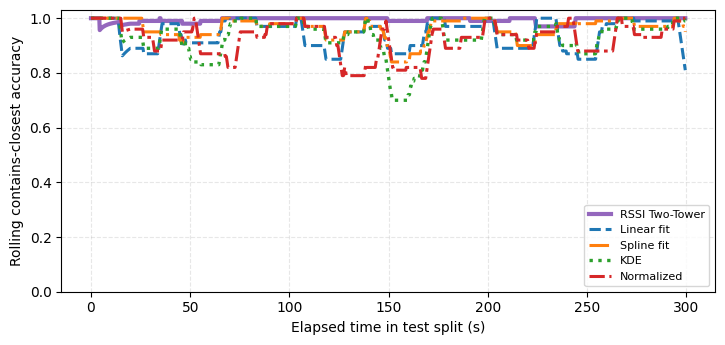

In [3]:
from pathlib import Path
import importlib
import sys

import torch

try:
    from IPython.display import display
except Exception:
    display = print

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.graces_quarters_baseline_comparison as gq_compare
import scripts.graces_quarters_rssi_two_tower as gq
gq_compare = importlib.reload(gq_compare)
gq = importlib.reload(gq)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATASET_PREFIX = gq.DEFAULT_PREFIX
MODEL_TAG = gq.DEFAULT_MODEL_TAG

print("Running Grace's Quarters comparison against the four RSSI baselines from notebook 07")
print("  model: RSSI-only two-tower")
print("  baselines: normalized top-3, linear path-loss posterior, spline posterior, KDE-hybrid posterior")

graces_comparison = gq_compare.run_comparison(
    PROJECT_ROOT,
    prefix=DATASET_PREFIX,
    model_tag=MODEL_TAG,
    device=DEVICE,
    rolling_window=100,
)

display(graces_comparison["summary"])
display(graces_comparison["merged"].head())


[report] Loading existing per-time method outputs from d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\graces_quarters_rssi_only_two_tower
[report] Mean accuracies:
  Two-Tower (RSSI): 99.40% over 1498 timestamps
  Linear: 93.19% over 1498 timestamps
  Spline: 95.93% over 1498 timestamps
  KDE: 92.99% over 1498 timestamps
  Norm.: 92.26% over 1498 timestamps
[report] Saved accuracy plot to d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\figures\graces_quarters_rssi_only_two_tower\graces_all_methods_report_time_vs_accuracy_double_column_styled.pdf
[runtime] Loading processed arrays and model-side metadata
[runtime] Benchmark setup: 1498 test timestamps, 5 repeats, 100 warmup steps, 10 nodes
[runtime] RSSI-only scalar extraction (10 sensors): warmup 100 steps, then 5 x 1498 timed calls
[runtime] RSSI-only scalar extraction (10 sensors): warmup done in 0.0s
[runtime] RSSI-only scalar extraction (10 sensors): repeat 1/5, step 500/1498, 6

,method,display_name,n_valid,mean_accuracy,std_error_binomial,n_common_times,mean_accuracy_common_times,rolling_window,source_csv
0,RSSI Two-Tower,Two-Tower (RSSI),1498,0.993992,0.001997,1498,0.993992,100,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
1,Linear fit,Linear,1498,0.931909,0.006508,1498,0.931909,100,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
2,Spline fit,Spline,1498,0.959279,0.005107,1498,0.959279,100,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
3,KDE,KDE,1498,0.929907,0.006596,1498,0.929907,100,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
4,Normalized,Norm.,1498,0.922563,0.006906,1498,0.922563,100,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...


,method,mean_accuracy,feature_mean_ms,context_state_mean_ms,decision_mean_ms,total_compute_mean_ms,total_compute_p95_component_sum_ms
0,Normalized,0.922563,0.001133,0.00000,0.008347,0.009480,0.023000
1,Linear fit,0.931909,0.001133,0.00000,0.102467,0.103600,0.175410
2,Spline fit,0.959279,0.001133,0.00000,0.134670,0.135803,0.228955
3,RSSI Two-Tower,0.993992,0.001133,0.01685,0.427355,0.445338,0.788025
4,KDE,0.929907,0.001133,0.00000,0.950824,0.951957,1.840845


,component,mean_ms,median_ms,p95_ms,p99_ms,std_ms,min_ms,max_ms,n_timed_calls,n_test_steps,n_repeats
0,RSSI-only scalar extraction (10 sensors),0.001133,0.0008,0.002900,0.005300,0.001545,0.0006,0.0735,7490,1498,5
1,RSSI Two-Tower context/state assembly,0.016850,0.0097,0.028155,0.065177,0.148016,0.0064,10.5907,7490,1498,5
2,Normalized decision,0.008347,0.0060,0.020100,0.032311,0.007425,0.0044,0.2776,7490,1498,5
3,Linear fit decision,0.102467,0.0891,0.172510,0.285575,0.058620,0.0821,3.1880,7490,1498,5
4,Spline fit decision,0.134670,0.1195,0.226055,0.308299,0.079598,0.1131,5.8834,7490,1498,5
5,KDE decision,0.950824,0.7606,1.837945,3.059740,0.500946,0.6639,14.6720,7490,1498,5
6,RSSI Two-Tower decision over static-action emb...,0.427355,0.3535,0.756970,1.283677,0.222007,0.3236,7.3251,7490,1498,5


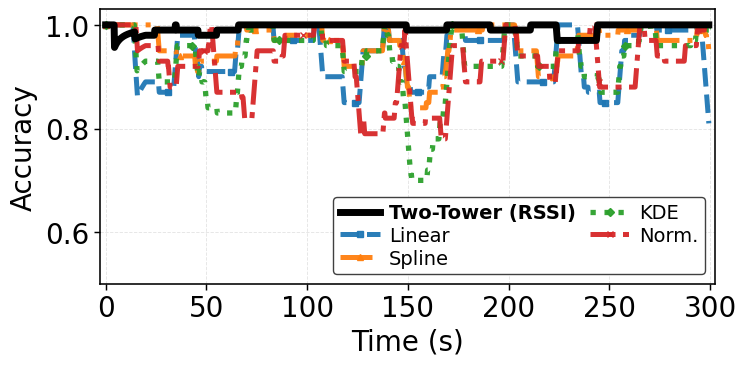

In [14]:
from pathlib import Path
import importlib
import sys

try:
    from IPython.display import display
except Exception:
    display = print

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.graces_quarters_baseline_comparison as gq_compare
import scripts.graces_quarters_rssi_two_tower as gq
gq_compare = importlib.reload(gq_compare)
gq = importlib.reload(gq)

REPORT_REPEATS = 5
REPORT_WARMUP = 100
REPORT_PROGRESS_EVERY = 500

graces_report = gq_compare.make_report_plot_and_runtime(
    PROJECT_ROOT,
    prefix=gq.DEFAULT_PREFIX,
    model_tag=gq.DEFAULT_MODEL_TAG,
    repeats=REPORT_REPEATS,
    warmup=REPORT_WARMUP,
    rolling_window=100,
    verbose=True,
    runtime_progress_every=REPORT_PROGRESS_EVERY,
)

display(graces_report["summary"])
display(graces_report["paper_runtime"])
display(graces_report["runtime_components"])


In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
